# Rolling Training Window Feasibility

This notebook tests whether rolling 30-day observation and 14-day label windows can produce a more viable training set for the RetailRocket purchase conversion task.

The analysis focuses on:

- **Formulation A:** broad observed visitor-item pairs.
- **Formulation C:** high-intent hybrid pairs with at least one add-to-cart event or at least two view events in the observation window.

No model training is performed here. The prepared Parquet file is used as read-only input.

## 1. Load Prepared Events

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EVENTS_PATH = PROJECT_ROOT / "data" / "interim" / "events_clean.parquet"
if not EVENTS_PATH.exists():
    raise FileNotFoundError(f"Prepared events file not found: {EVENTS_PATH}")

events = pd.read_parquet(EVENTS_PATH)
events[["timestamp", "visitorid", "event", "itemid", "transactionid"]].head()

,timestamp,visitorid,event,itemid,transactionid
0,2015-05-03 03:00:04.384,693516,addtocart,297662,NaN
1,2015-05-03 03:00:11.289,829044,view,60987,NaN
2,2015-05-03 03:00:13.048,652699,view,252860,NaN
3,2015-05-03 03:00:24.154,1125936,view,33661,NaN
4,2015-05-03 03:00:26.228,693516,view,297662,NaN


## 2. Fixed Validation/Test Windows

In [2]:
validation_window = {
    "split": "validation",
    "observation_start": "2015-06-16",
    "observation_end": "2015-07-15",
    "label_start": "2015-07-16",
    "label_end": "2015-07-29",
}

test_window = {
    "split": "test",
    "observation_start": "2015-07-30",
    "observation_end": "2015-08-28",
    "label_start": "2015-08-29",
    "label_end": "2015-09-11",
}

current_single_train_window = {
    "snapshot_id": "single_train",
    "observation_start": "2015-05-03",
    "observation_end": "2015-06-01",
    "label_start": "2015-06-02",
    "label_end": "2015-06-15",
}

display(pd.DataFrame([validation_window, test_window]))

def inclusive_date_mask(df: pd.DataFrame, start_date: str, end_date: str) -> pd.Series:
    start = pd.Timestamp(start_date)
    end_exclusive = pd.Timestamp(end_date) + pd.Timedelta(days=1)
    return df["timestamp"].ge(start) & df["timestamp"].lt(end_exclusive)

,split,observation_start,observation_end,label_start,label_end
0,validation,2015-06-16,2015-07-15,2015-07-16,2015-07-29
1,test,2015-07-30,2015-08-28,2015-08-29,2015-09-11


## 3. Rolling Training Window Policies

Rolling snapshots use a 30-day observation window followed by a 14-day label window. Snapshot starts are stepped by 7 calendar days where possible.

- **Policy 1, strict chronology:** include only training windows whose label window ends before the validation observation window begins (`train_label_end < 2015-06-16`). This is the most conservative option.
- **Policy 2, practical pre-validation-label:** include training windows whose label window ends before the validation label window begins (`train_label_end < 2015-07-16`). This allows more training snapshots while still avoiding the validation label period itself, but it overlaps with the validation observation period.

In [3]:
def generate_rolling_windows(
    first_observation_start: str,
    latest_label_end: str,
    observation_days: int = 30,
    label_days: int = 14,
    step_days: int = 7,
) -> pd.DataFrame:
    rows = []
    observation_start = pd.Timestamp(first_observation_start)
    latest_label_end_ts = pd.Timestamp(latest_label_end)
    snapshot_num = 1

    while True:
        observation_end = observation_start + pd.Timedelta(days=observation_days - 1)
        label_start = observation_end + pd.Timedelta(days=1)
        label_end = label_start + pd.Timedelta(days=label_days - 1)

        if label_end > latest_label_end_ts:
            break

        rows.append(
            {
                "snapshot_id": f"roll_{snapshot_num:02d}",
                "observation_start": observation_start.date().isoformat(),
                "observation_end": observation_end.date().isoformat(),
                "label_start": label_start.date().isoformat(),
                "label_end": label_end.date().isoformat(),
            }
        )
        snapshot_num += 1
        observation_start += pd.Timedelta(days=step_days)

    return pd.DataFrame(rows)

dataset_min_date = events["timestamp"].min().date().isoformat()
candidate_windows = generate_rolling_windows(
    first_observation_start=dataset_min_date,
    latest_label_end="2015-07-15",
)

candidate_windows["policy_1_strict"] = pd.to_datetime(candidate_windows["label_end"]).lt(pd.Timestamp("2015-06-16"))
candidate_windows["policy_2_pre_validation_label"] = pd.to_datetime(candidate_windows["label_end"]).lt(pd.Timestamp("2015-07-16"))
candidate_windows["policy_membership"] = np.select(
    [
        candidate_windows["policy_1_strict"],
        candidate_windows["policy_2_pre_validation_label"],
    ],
    [
        "Policy 1 and Policy 2",
        "Policy 2 only",
    ],
    default="Excluded",
)

display(candidate_windows)

,snapshot_id,observation_start,observation_end,label_start,label_end,policy_1_strict,policy_2_pre_validation_label,policy_membership
0,roll_01,2015-05-03,2015-06-01,2015-06-02,2015-06-15,True,True,Policy 1 and Policy 2
1,roll_02,2015-05-10,2015-06-08,2015-06-09,2015-06-22,False,True,Policy 2 only
2,roll_03,2015-05-17,2015-06-15,2015-06-16,2015-06-29,False,True,Policy 2 only
3,roll_04,2015-05-24,2015-06-22,2015-06-23,2015-07-06,False,True,Policy 2 only
4,roll_05,2015-05-31,2015-06-29,2015-06-30,2015-07-13,False,True,Policy 2 only


## 4. Candidate Formulation Helpers

In [4]:
def pair_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df[["visitorid", "itemid"]].drop_duplicates().reset_index(drop=True)

def candidates_a(obs: pd.DataFrame) -> pd.DataFrame:
    return pair_columns(obs)

def candidates_c(obs: pd.DataFrame) -> pd.DataFrame:
    pair_event_counts = (
        obs.groupby(["visitorid", "itemid", "event"])
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    for event_name in ["view", "addtocart"]:
        if event_name not in pair_event_counts.columns:
            pair_event_counts[event_name] = 0
    return pair_event_counts.loc[
        pair_event_counts["addtocart"].ge(1) | pair_event_counts["view"].ge(2),
        ["visitorid", "itemid"],
    ].reset_index(drop=True)

formulation_functions = {
    "A - Broad Observed-Pair Baseline": candidates_a,
    "C - High-Intent Hybrid Candidate Pairs": candidates_c,
}

formulation_codes = {
    "A - Broad Observed-Pair Baseline": "A",
    "C - High-Intent Hybrid Candidate Pairs": "C",
}

## 5. Per-Window Metrics

In [5]:
def compute_window_metrics(window: dict, formulation: str) -> dict:
    obs = events.loc[inclusive_date_mask(events, window["observation_start"], window["observation_end"])]
    label = events.loc[inclusive_date_mask(events, window["label_start"], window["label_end"])]

    candidate_pairs = formulation_functions[formulation](obs)
    label_positive_pairs = pair_columns(label.loc[label["event"].eq("transaction")])
    matched_positive_pairs = candidate_pairs.merge(
        label_positive_pairs,
        on=["visitorid", "itemid"],
        how="inner",
    )

    candidate_pair_count = len(candidate_pairs)
    label_positive_pair_count = len(label_positive_pairs)
    matched_positive_pair_count = len(matched_positive_pairs)
    negative_pair_count = candidate_pair_count - matched_positive_pair_count

    return {
        "snapshot_id": window["snapshot_id"],
        "observation_start": window["observation_start"],
        "observation_end": window["observation_end"],
        "label_start": window["label_start"],
        "label_end": window["label_end"],
        "formulation": formulation,
        "formulation_code": formulation_codes[formulation],
        "candidate_pair_count": candidate_pair_count,
        "label_positive_pair_count": label_positive_pair_count,
        "matched_positive_pair_count": matched_positive_pair_count,
        "candidate_positive_rate": matched_positive_pair_count / candidate_pair_count if candidate_pair_count else np.nan,
        "label_positive_coverage": matched_positive_pair_count / label_positive_pair_count if label_positive_pair_count else np.nan,
        "negative_pair_count": negative_pair_count,
        "negative_to_positive_ratio": negative_pair_count / matched_positive_pair_count if matched_positive_pair_count else np.inf,
    }

metric_rows = []
for window in candidate_windows.to_dict("records"):
    for formulation in formulation_functions:
        metric_rows.append(compute_window_metrics(window, formulation))

rolling_metrics = pd.DataFrame(metric_rows)
rolling_metrics = rolling_metrics.merge(
    candidate_windows[["snapshot_id", "policy_1_strict", "policy_2_pre_validation_label", "policy_membership"]],
    on="snapshot_id",
    how="left",
)

display(rolling_metrics)

,snapshot_id,observation_start,observation_end,label_start,label_end,formulation,formulation_code,candidate_pair_count,label_positive_pair_count,matched_positive_pair_count,candidate_positive_rate,label_positive_coverage,negative_pair_count,negative_to_positive_ratio,policy_1_strict,policy_2_pre_validation_label,policy_membership
0,roll_01,2015-05-03,2015-06-01,2015-06-02,2015-06-15,A - Broad Observed-Pair Baseline,A,477110,2045,119,0.000249,0.058191,476991,4008.327731,True,True,Policy 1 and Policy 2
1,roll_01,2015-05-03,2015-06-01,2015-06-02,2015-06-15,C - High-Intent Hybrid Candidate Pairs,C,77211,2045,87,0.001127,0.042543,77124,886.482759,True,True,Policy 1 and Policy 2
2,roll_02,2015-05-10,2015-06-08,2015-06-09,2015-06-22,A - Broad Observed-Pair Baseline,A,484176,2203,98,0.000202,0.044485,484078,4939.571429,False,True,Policy 2 only
3,roll_02,2015-05-10,2015-06-08,2015-06-09,2015-06-22,C - High-Intent Hybrid Candidate Pairs,C,78416,2203,73,0.000931,0.033137,78343,1073.191781,False,True,Policy 2 only
4,roll_03,2015-05-17,2015-06-15,2015-06-16,2015-06-29,A - Broad Observed-Pair Baseline,A,479581,2436,107,0.000223,0.043924,479474,4481.065421,False,True,Policy 2 only
5,roll_03,2015-05-17,2015-06-15,2015-06-16,2015-06-29,C - High-Intent Hybrid Candidate Pairs,C,77087,2436,73,0.000947,0.029967,77014,1054.986301,False,True,Policy 2 only
6,roll_04,2015-05-24,2015-06-22,2015-06-23,2015-07-06,A - Broad Observed-Pair Baseline,A,470060,2213,104,0.000221,0.046995,469956,4518.807692,False,True,Policy 2 only
7,roll_04,2015-05-24,2015-06-22,2015-06-23,2015-07-06,C - High-Intent Hybrid Candidate Pairs,C,76819,2213,78,0.001015,0.035246,76741,983.858974,False,True,Policy 2 only
8,roll_05,2015-05-31,2015-06-29,2015-06-30,2015-07-13,A - Broad Observed-Pair Baseline,A,467643,2296,107,0.000229,0.046603,467536,4369.495327,False,True,Policy 2 only
9,roll_05,2015-05-31,2015-06-29,2015-06-30,2015-07-13,C - High-Intent Hybrid Candidate Pairs,C,76976,2296,64,0.000831,0.027875,76912,1201.750000,False,True,Policy 2 only


## 6. Pooled Rolling-Train Metrics

In [6]:
def candidate_pairs_for_window(window: dict, formulation: str) -> pd.DataFrame:
    obs = events.loc[inclusive_date_mask(events, window["observation_start"], window["observation_end"])]
    candidates = formulation_functions[formulation](obs)
    return candidates.assign(snapshot_id=window["snapshot_id"])

def positive_pairs_for_window(window: dict) -> pd.DataFrame:
    label = events.loc[inclusive_date_mask(events, window["label_start"], window["label_end"])]
    return pair_columns(label.loc[label["event"].eq("transaction")]).assign(snapshot_id=window["snapshot_id"])

def pooled_metrics(policy_name: str, policy_mask_col: str, formulation: str) -> dict:
    policy_windows = candidate_windows.loc[candidate_windows[policy_mask_col]].copy()
    candidate_frames = []
    positive_frames = []
    matched_frames = []

    for window in policy_windows.to_dict("records"):
        candidates = candidate_pairs_for_window(window, formulation)
        positives = positive_pairs_for_window(window)
        matched = candidates.merge(
            positives,
            on=["snapshot_id", "visitorid", "itemid"],
            how="inner",
        )
        candidate_frames.append(candidates)
        positive_frames.append(positives)
        matched_frames.append(matched)

    candidates_all = pd.concat(candidate_frames, ignore_index=True) if candidate_frames else pd.DataFrame(columns=["snapshot_id", "visitorid", "itemid"])
    matched_all = pd.concat(matched_frames, ignore_index=True) if matched_frames else pd.DataFrame(columns=["snapshot_id", "visitorid", "itemid"])

    pooled_candidate_sample_count = len(candidates_all)
    pooled_matched_positive_sample_count = len(matched_all)
    pooled_negative_sample_count = pooled_candidate_sample_count - pooled_matched_positive_sample_count

    unique_candidate_pairs = candidates_all[["visitorid", "itemid"]].drop_duplicates()
    unique_matched_positive_pairs = matched_all[["visitorid", "itemid"]].drop_duplicates()
    repeated_positive_samples = pooled_matched_positive_sample_count - len(unique_matched_positive_pairs)

    return {
        "policy": policy_name,
        "formulation": formulation,
        "formulation_code": formulation_codes[formulation],
        "train_snapshot_count": len(policy_windows),
        "pooled_candidate_sample_count": pooled_candidate_sample_count,
        "pooled_matched_positive_sample_count": pooled_matched_positive_sample_count,
        "pooled_positive_rate": (
            pooled_matched_positive_sample_count / pooled_candidate_sample_count
            if pooled_candidate_sample_count
            else np.nan
        ),
        "pooled_negative_to_positive_ratio": (
            pooled_negative_sample_count / pooled_matched_positive_sample_count
            if pooled_matched_positive_sample_count
            else np.inf
        ),
        "unique_candidate_pair_count": len(unique_candidate_pairs),
        "unique_matched_positive_pair_count": len(unique_matched_positive_pairs),
        "repeated_matched_positive_sample_count": repeated_positive_samples,
    }

pooled_rows = []
for policy_name, policy_col in [
    ("Policy 1 - strict chronology", "policy_1_strict"),
    ("Policy 2 - pre-validation-label", "policy_2_pre_validation_label"),
]:
    for formulation in formulation_functions:
        pooled_rows.append(pooled_metrics(policy_name, policy_col, formulation))

pooled_summary = pd.DataFrame(pooled_rows)
display(pooled_summary)

,policy,formulation,formulation_code,train_snapshot_count,pooled_candidate_sample_count,pooled_matched_positive_sample_count,pooled_positive_rate,pooled_negative_to_positive_ratio,unique_candidate_pair_count,unique_matched_positive_pair_count,repeated_matched_positive_sample_count
0,Policy 1 - strict chronology,A - Broad Observed-Pair Baseline,A,1,477110,119,0.000249,4008.327731,477110,119,0
1,Policy 1 - strict chronology,C - High-Intent Hybrid Candidate Pairs,C,1,77211,87,0.001127,886.482759,77211,87,0
2,Policy 2 - pre-validation-label,A - Broad Observed-Pair Baseline,A,5,2378570,535,0.000225,4444.925234,909468,432,103
3,Policy 2 - pre-validation-label,C - High-Intent Hybrid Candidate Pairs,C,5,386509,375,0.000970,1029.690667,149409,300,75


## 7. Rolling Training vs Current Single-Window Baseline

In [7]:
single_rows = []
for formulation in formulation_functions:
    single_metrics = compute_window_metrics(current_single_train_window, formulation)
    single_rows.append(
        {
            "scenario": f"Current single-window Train {single_metrics['formulation_code']}",
            "formulation_code": single_metrics["formulation_code"],
            "train_snapshot_count": 1,
            "pooled_candidate_sample_count": single_metrics["candidate_pair_count"],
            "pooled_matched_positive_sample_count": single_metrics["matched_positive_pair_count"],
            "pooled_positive_rate": single_metrics["candidate_positive_rate"],
            "pooled_negative_to_positive_ratio": single_metrics["negative_to_positive_ratio"],
            "unique_matched_positive_pair_count": single_metrics["matched_positive_pair_count"],
        }
    )

rolling_comparison_rows = []
for row in pooled_summary.to_dict("records"):
    rolling_comparison_rows.append(
        {
            "scenario": f"{row['policy']} {row['formulation_code']}",
            "formulation_code": row["formulation_code"],
            "train_snapshot_count": row["train_snapshot_count"],
            "pooled_candidate_sample_count": row["pooled_candidate_sample_count"],
            "pooled_matched_positive_sample_count": row["pooled_matched_positive_sample_count"],
            "pooled_positive_rate": row["pooled_positive_rate"],
            "pooled_negative_to_positive_ratio": row["pooled_negative_to_positive_ratio"],
            "unique_matched_positive_pair_count": row["unique_matched_positive_pair_count"],
        }
    )

baseline_vs_rolling = pd.DataFrame(single_rows + rolling_comparison_rows)
display(baseline_vs_rolling)

readable_baseline_vs_rolling = baseline_vs_rolling.copy()
readable_baseline_vs_rolling["pooled_positive_rate"] = readable_baseline_vs_rolling["pooled_positive_rate"].map(lambda x: f"{x:.4%}")
readable_baseline_vs_rolling["pooled_negative_to_positive_ratio"] = readable_baseline_vs_rolling["pooled_negative_to_positive_ratio"].map(lambda x: f"{x:,.1f}:1")
display(readable_baseline_vs_rolling)

,scenario,formulation_code,train_snapshot_count,pooled_candidate_sample_count,pooled_matched_positive_sample_count,pooled_positive_rate,pooled_negative_to_positive_ratio,unique_matched_positive_pair_count
0,Current single-window Train A,A,1,477110,119,0.000249,4008.327731,119
1,Current single-window Train C,C,1,77211,87,0.001127,886.482759,87
2,Policy 1 - strict chronology A,A,1,477110,119,0.000249,4008.327731,119
3,Policy 1 - strict chronology C,C,1,77211,87,0.001127,886.482759,87
4,Policy 2 - pre-validation-label A,A,5,2378570,535,0.000225,4444.925234,432
5,Policy 2 - pre-validation-label C,C,5,386509,375,0.000970,1029.690667,300


,scenario,formulation_code,train_snapshot_count,pooled_candidate_sample_count,pooled_matched_positive_sample_count,pooled_positive_rate,pooled_negative_to_positive_ratio,unique_matched_positive_pair_count
0,Current single-window Train A,A,1,477110,119,0.0249%,"4,008.3:1",119
1,Current single-window Train C,C,1,77211,87,0.1127%,886.5:1,87
2,Policy 1 - strict chronology A,A,1,477110,119,0.0249%,"4,008.3:1",119
3,Policy 1 - strict chronology C,C,1,77211,87,0.1127%,886.5:1,87
4,Policy 2 - pre-validation-label A,A,5,2378570,535,0.0225%,"4,444.9:1",432
5,Policy 2 - pre-validation-label C,C,5,386509,375,0.0970%,"1,029.7:1",300


## Decision Rubric: Is Rolling-Window Formulation C Viable?

1. We prefer Formulation C over A if it still delivers a meaningful positive-rate improvement.
2. Rolling training is considered substantially helpful if pooled matched positive training samples rise from 87 into the several-hundred range or higher, without the gain being entirely due to a tiny number of repeated duplicate pairs.
3. 300+ pooled matched-positive samples would be a noticeable improvement.
4. 500+ pooled matched-positive samples would make the downstream modeling experiment much more credible.
5. If rolling C remains very low, we should pause before dataset building and revisit the target definition more fundamentally.

## 8. Visualizations

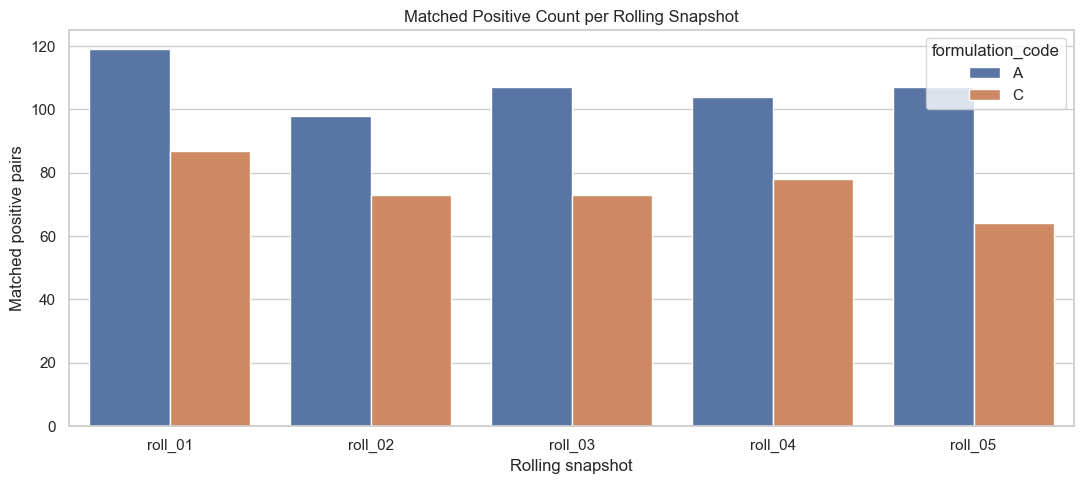

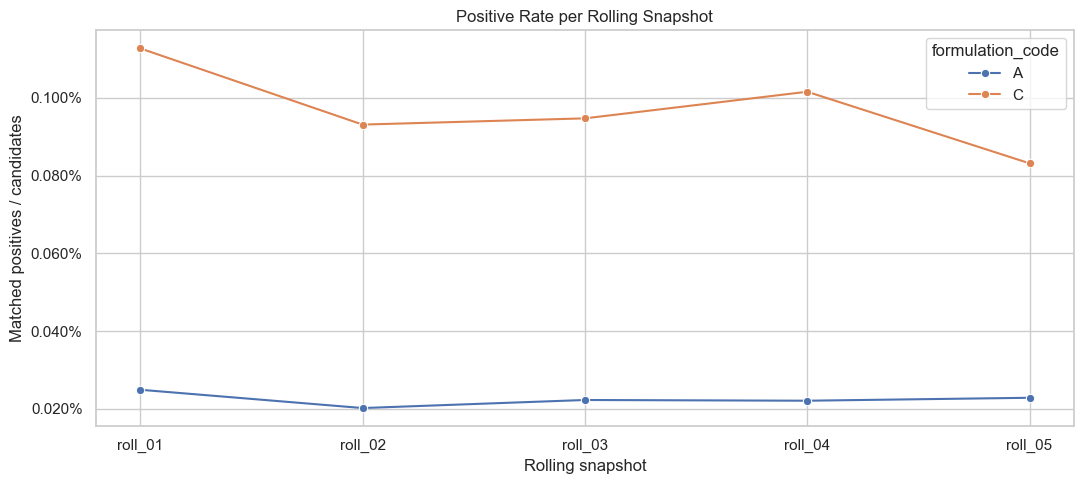

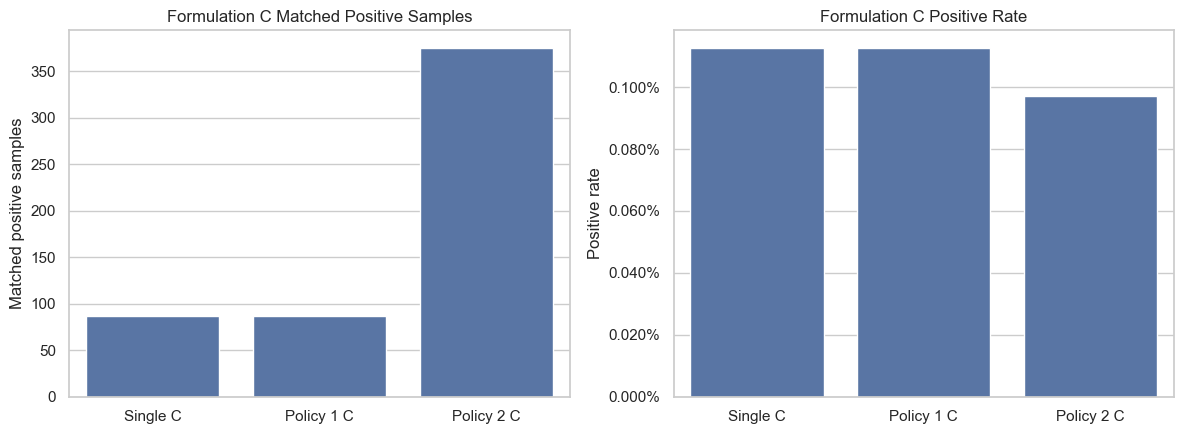

In [8]:
plot_metrics = rolling_metrics.copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=plot_metrics,
    x="snapshot_id",
    y="matched_positive_pair_count",
    hue="formulation_code",
    ax=ax,
)
ax.set_title("Matched Positive Count per Rolling Snapshot")
ax.set_xlabel("Rolling snapshot")
ax.set_ylabel("Matched positive pairs")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(
    data=plot_metrics,
    x="snapshot_id",
    y="candidate_positive_rate",
    hue="formulation_code",
    marker="o",
    ax=ax,
)
ax.set_title("Positive Rate per Rolling Snapshot")
ax.set_xlabel("Rolling snapshot")
ax.set_ylabel("Matched positives / candidates")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3%}"))
plt.tight_layout()
plt.show()

c_summary = baseline_vs_rolling.loc[
    baseline_vs_rolling["scenario"].isin(
        [
            "Current single-window Train C",
            "Policy 1 - strict chronology C",
            "Policy 2 - pre-validation-label C",
        ]
    )
].copy()
c_summary["short_scenario"] = c_summary["scenario"].map(
    {
        "Current single-window Train C": "Single C",
        "Policy 1 - strict chronology C": "Policy 1 C",
        "Policy 2 - pre-validation-label C": "Policy 2 C",
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(
    data=c_summary,
    x="short_scenario",
    y="pooled_matched_positive_sample_count",
    ax=axes[0],
)
axes[0].set_title("Formulation C Matched Positive Samples")
axes[0].set_xlabel("")
axes[0].set_ylabel("Matched positive samples")

sns.barplot(
    data=c_summary,
    x="short_scenario",
    y="pooled_positive_rate",
    ax=axes[1],
)
axes[1].set_title("Formulation C Positive Rate")
axes[1].set_xlabel("")
axes[1].set_ylabel("Positive rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3%}"))

plt.tight_layout()
plt.show()

## 9. Notebook Conclusion

In [9]:
pooled_lookup = pooled_summary.set_index(["policy", "formulation_code"])
baseline_lookup = baseline_vs_rolling.set_index("scenario")

p1_c = pooled_lookup.loc[("Policy 1 - strict chronology", "C")]
p2_c = pooled_lookup.loc[("Policy 2 - pre-validation-label", "C")]
single_c = baseline_lookup.loc["Current single-window Train C"]

conclusion = f'''
### Conclusion

1. **Rolling windows help only under the less conservative policy.** Formulation C has {single_c["pooled_matched_positive_sample_count"]:,.0f} matched-positive samples in the current single train window. Policy 1 also has {p1_c["pooled_matched_positive_sample_count"]:,.0f} because the available data starts too late to create additional strict-pre-validation snapshots. Policy 2 increases this to {p2_c["pooled_matched_positive_sample_count"]:,.0f}.

2. **Formulation C becomes more viable, but remains sparse.** Policy 2 crosses the 300-sample improvement threshold, while Policy 1 does not. Neither reaches the preferred 500+ matched-positive sample level.

3. **`src/02_build_datasets.py` should implement rolling-window train plus fixed validation/test, not single-window only.** The builder should be configurable and support Formulation C as the leading V1 target plus Formulation A as a broad diagnostic baseline.

4. **Policy 2 is preferable for the next implementation phase** because it provides substantially more Formulation C positives while still avoiding the validation label period itself. The tradeoff is that Policy 2 training observations can overlap the validation observation window, so evaluation remains chronological by labels but less conservative than Policy 1.

5. **Validation/test sparsity remains the main caveat.** Rolling windows improve training sample count only; they do not change the fixed validation/test windows. Reported validation and test metrics may still be noisy because matched-positive counts remain limited.
'''

display(Markdown(conclusion))


### Conclusion

1. **Rolling windows help only under the less conservative policy.** Formulation C has 87 matched-positive samples in the current single train window. Policy 1 also has 87 because the available data starts too late to create additional strict-pre-validation snapshots. Policy 2 increases this to 375.

2. **Formulation C becomes more viable, but remains sparse.** Policy 2 crosses the 300-sample improvement threshold, while Policy 1 does not. Neither reaches the preferred 500+ matched-positive sample level.

3. **`src/02_build_datasets.py` should implement rolling-window train plus fixed validation/test, not single-window only.** The builder should be configurable and support Formulation C as the leading V1 target plus Formulation A as a broad diagnostic baseline.

4. **Policy 2 is preferable for the next implementation phase** because it provides substantially more Formulation C positives while still avoiding the validation label period itself. The tradeoff is that Policy 2 training observations can overlap the validation observation window, so evaluation remains chronological by labels but less conservative than Policy 1.

5. **Validation/test sparsity remains the main caveat.** Rolling windows improve training sample count only; they do not change the fixed validation/test windows. Reported validation and test metrics may still be noisy because matched-positive counts remain limited.
